## Deep Learning

In [22]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt

# reproducibility
RNG_SEED = 42
np.random.seed(RNG_SEED)

In [23]:
csv_path = "archive/english.csv"
df = pd.read_csv(csv_path)
print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['image', 'label']
                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0


In [21]:
# params
ROOT = "archive"          # csv paths already contain "Img/..." so join ROOT + df['image']
IMG_SIZE = (28, 28)       # width, height

images = []
labels = []
missing = []

for idx, row in df.iterrows():
    img_rel = row["image"]       # e.g. "Img/img001-001.png"
    label_raw = row["label"]     # may be int-like or str
    img_path = os.path.join(ROOT, img_rel)
    if not os.path.exists(img_path):
        missing.append(img_path)
        continue
    im = Image.open(img_path).convert("L")        # grayscale
    im = im.resize(IMG_SIZE)                      # resize
    arr = np.asarray(im, dtype=np.float32).flatten() / 255.0
    images.append(arr)
    labels.append(label_raw)

print("Missing files (count):", len(missing))
X = np.vstack(images)   # shape (N, D)
y_raw = np.array(labels)  # raw labels (strings or numbers)
print("Loaded X:", X.shape, " y:", y_raw.shape, " unique labels:", np.unique(y_raw).shape[0])


Missing files (count): 0
Loaded X: (3410, 784)  y: (3410,)  unique labels: 62


In [25]:
# encode to 0..C-1 for indexing in perceptron
le = LabelEncoder()
y = le.fit_transform(y_raw)   # y is integer array

# stratified splits
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED, stratify=y)

# carve out validation from training
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RNG_SEED, stratify=y_train_full)

print("Shapes -> train:", X_train.shape, y_train.shape,
      "val:", X_val.shape, y_val.shape, "test:", X_test.shape, y_test.shape)
print("Classes (label -> idx) example:", list(zip(le.classes_[:8], range(8))))


Shapes -> train: (2182, 784) (2182,) val: (546, 784) (546,) test: (682, 784) (682,)
Classes (label -> idx) example: [(np.str_('0'), 0), (np.str_('1'), 1), (np.str_('2'), 2), (np.str_('3'), 3), (np.str_('4'), 4), (np.str_('5'), 5), (np.str_('6'), 6), (np.str_('7'), 7)]


In [26]:
class PerceptronPLA:
    """
    Multiclass perceptron (one weight vector per class).
    Predict: argmax_c (W_c · x + b_c)
    Update when prediction != true:
      W_true += lr * x
      b_true += lr
      W_pred -= lr * x
      b_pred -= lr
    """
    def __init__(self, n_features, n_classes, lr=1.0, epochs=20, shuffle=True, random_state=None):
        self.lr = lr
        self.epochs = epochs
        self.shuffle = shuffle
        self.random_state = random_state if random_state is not None else 0
        rng = np.random.RandomState(self.random_state)
        self.W = rng.normal(0, 1e-3, size=(n_classes, n_features)).astype(np.float32)
        self.b = np.zeros((n_classes,), dtype=np.float32)
        self.n_classes = n_classes
        self.history = {"epoch": [], "mistakes": [], "train_acc": []}

    def decision_function(self, X):
        # raw scores shape: (N, C)
        return X.dot(self.W.T) + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.argmax(scores, axis=1)

    def fit(self, X, y, verbose=True):
        N = X.shape[0]
        idxs = np.arange(N)
        for ep in range(1, self.epochs + 1):
            if self.shuffle:
                np.random.shuffle(idxs)
            mistakes = 0
            for i in idxs:
                xi = X[i]
                yi = int(y[i])
                scores = self.W.dot(xi) + self.b
                yhat = int(np.argmax(scores))
                if yhat != yi:
                    # update
                    self.W[yi] += self.lr * xi
                    self.b[yi] += self.lr
                    self.W[yhat] -= self.lr * xi
                    self.b[yhat] -= self.lr
                    mistakes += 1
            train_pred = self.predict(X)
            train_acc = float((train_pred == y).mean())
            self.history["epoch"].append(ep)
            self.history["mistakes"].append(mistakes)
            self.history["train_acc"].append(train_acc)
            if verbose:
                print(f"[Epoch {ep:>2}] mistakes={mistakes:>5}  train_acc={train_acc:.4f}")


In [27]:
n_classes = len(le.classes_)
model = PerceptronPLA(n_features=X.shape[1], n_classes=n_classes, lr=1.0, epochs=10, shuffle=True, random_state=RNG_SEED)
model.fit(X_train, y_train)


[Epoch  1] mistakes= 2137  train_acc=0.0160
[Epoch  2] mistakes= 2097  train_acc=0.0202
[Epoch  3] mistakes= 2004  train_acc=0.1526
[Epoch  4] mistakes= 1983  train_acc=0.0477
[Epoch  5] mistakes= 1954  train_acc=0.1201
[Epoch  6] mistakes= 1904  train_acc=0.1819
[Epoch  7] mistakes= 1851  train_acc=0.1682
[Epoch  8] mistakes= 1880  train_acc=0.1279
[Epoch  9] mistakes= 1844  train_acc=0.1719
[Epoch 10] mistakes= 1816  train_acc=0.2328


In [17]:
num_classes = len(np.unique(y_encoded))
model = Perceptron(input_dim=X.shape[1], num_classes=num_classes, lr=0.01, epochs=10)
model.fit(X_train, y_train)


Epoch 1/10, Errors: 2664
Epoch 2/10, Errors: 2581
Epoch 3/10, Errors: 2535
Epoch 4/10, Errors: 2434
Epoch 5/10, Errors: 2388
Epoch 6/10, Errors: 2366
Epoch 7/10, Errors: 2332
Epoch 8/10, Errors: 2269
Epoch 9/10, Errors: 2259
Epoch 10/10, Errors: 2271


In [28]:
from itertools import product

def grid_search_pla(X_train, y_train, X_val, y_val, lr_list, epochs_list, shuffle_list, random_state=RNG_SEED):
    best_cfg = None
    best_acc = -1.0
    results = []
    for lr, ep, sh in product(lr_list, epochs_list, shuffle_list):
        model = PerceptronPLA(n_features=X_train.shape[1], n_classes=n_classes, lr=lr, epochs=ep, shuffle=sh, random_state=random_state)
        model.fit(X_train, y_train, verbose=False)
        val_pred = model.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        results.append({"lr": lr, "epochs": ep, "shuffle": sh, "val_acc": float(val_acc)})
        print(f"[grid] lr={lr:<4} epochs={ep:<3} shuffle={sh} -> val_acc={val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            best_cfg = {"lr": lr, "epochs": ep, "shuffle": sh}
    return best_cfg, best_acc, results

# run grid
lr_list = [1.0, 0.1, 0.01]
epochs_list = [10, 20, 30]
shuffle_list = [True]

best_cfg, best_val_acc, grid_results = grid_search_pla(X_train, y_train, X_val, y_val, lr_list, epochs_list, shuffle_list)
print("Best config:", best_cfg, "best_val_acc:", best_val_acc)


[grid] lr=1.0  epochs=10  shuffle=True -> val_acc=0.1538
[grid] lr=1.0  epochs=20  shuffle=True -> val_acc=0.1355
[grid] lr=1.0  epochs=30  shuffle=True -> val_acc=0.1886
[grid] lr=0.1  epochs=10  shuffle=True -> val_acc=0.1337
[grid] lr=0.1  epochs=20  shuffle=True -> val_acc=0.1099
[grid] lr=0.1  epochs=30  shuffle=True -> val_acc=0.1502
[grid] lr=0.01 epochs=10  shuffle=True -> val_acc=0.1245
[grid] lr=0.01 epochs=20  shuffle=True -> val_acc=0.1685
[grid] lr=0.01 epochs=30  shuffle=True -> val_acc=0.1740
Best config: {'lr': 1.0, 'epochs': 30, 'shuffle': True} best_val_acc: 0.18864468864468864


In [29]:
# combine train + val
X_retrain = np.vstack([X_train, X_val])
y_retrain = np.hstack([y_train, y_val])

model_best = PerceptronPLA(n_features=X.shape[1], n_classes=n_classes,
                           lr=best_cfg["lr"], epochs=best_cfg["epochs"], shuffle=best_cfg["shuffle"],
                           random_state=RNG_SEED)
model_best.fit(X_retrain, y_retrain)


[Epoch  1] mistakes= 2658  train_acc=0.0161
[Epoch  2] mistakes= 2575  train_acc=0.0847
[Epoch  3] mistakes= 2508  train_acc=0.1580
[Epoch  4] mistakes= 2380  train_acc=0.1844
[Epoch  5] mistakes= 2384  train_acc=0.1525
[Epoch  6] mistakes= 2313  train_acc=0.1741
[Epoch  7] mistakes= 2321  train_acc=0.1631
[Epoch  8] mistakes= 2321  train_acc=0.0913
[Epoch  9] mistakes= 2302  train_acc=0.1723
[Epoch 10] mistakes= 2273  train_acc=0.1408
[Epoch 11] mistakes= 2237  train_acc=0.2009
[Epoch 12] mistakes= 2271  train_acc=0.1034
[Epoch 13] mistakes= 2201  train_acc=0.2474
[Epoch 14] mistakes= 2160  train_acc=0.2045
[Epoch 15] mistakes= 2110  train_acc=0.2401
[Epoch 16] mistakes= 2104  train_acc=0.1602
[Epoch 17] mistakes= 2106  train_acc=0.2518
[Epoch 18] mistakes= 2109  train_acc=0.2240
[Epoch 19] mistakes= 2092  train_acc=0.2903
[Epoch 20] mistakes= 2118  train_acc=0.1818
[Epoch 21] mistakes= 2084  train_acc=0.3284
[Epoch 22] mistakes= 2057  train_acc=0.3028
[Epoch 23] mistakes= 2048  train

Test accuracy: 0.16422287390029325
Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        11
           2       0.33      0.09      0.14        11
           3       0.50      0.18      0.27        11
           4       0.00      0.00      0.00        11
           5       0.11      0.18      0.13        11
           6       0.11      0.73      0.19        11
           7       0.50      0.18      0.27        11
           8       0.00      0.00      0.00        11
           9       0.67      0.18      0.29        11
           A       0.00      0.00      0.00        11
           B       0.00      0.00      0.00        11
           C       1.00      0.18      0.31        11
           D       0.25      0.27      0.26        11
           E       0.40      0.18      0.25        11
           F       0.00      0.00      0.00        11
           G       1.0

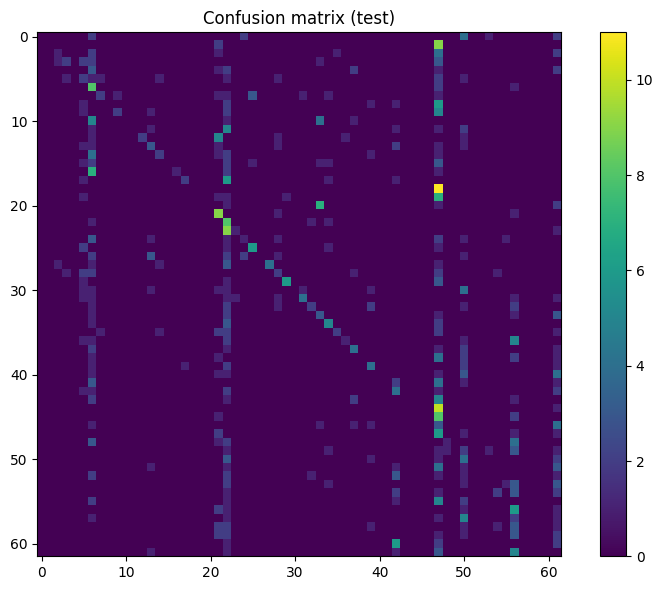

In [30]:
# predictions and basic metrics
y_pred = model_best.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print("Classification report:\n", classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_], zero_division=0))

# confusion matrix (huge for 62 classes; we'll show it but without tick labels to avoid clutter)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion matrix (test)")
plt.colorbar()
plt.tight_layout()
plt.show()


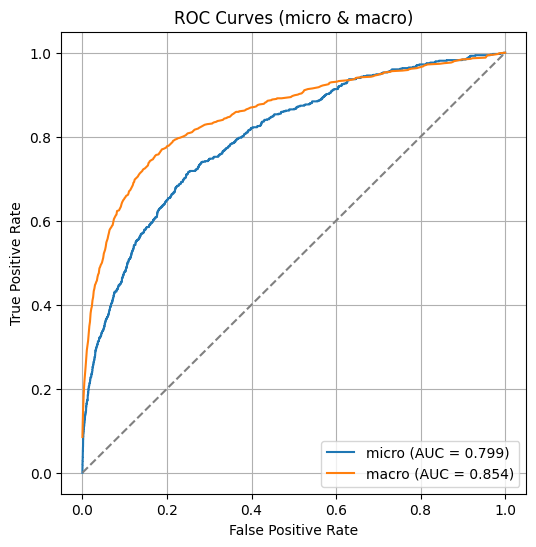

In [31]:
# decision scores
scores_test = model_best.decision_function(X_test)   # shape (N_test, C)

# binarize true labels
lb = LabelBinarizer()
Y_test_bin = lb.fit_transform(y_test)
# if only two classes, LabelBinarizer returns shape (N,1); fix that
if Y_test_bin.shape[1] == 1:
    Y_test_bin = np.hstack([1 - Y_test_bin, Y_test_bin])

# per-class ROC AUC
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], scores_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(Y_test_bin.ravel(), scores_test.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# macro-average (aggregate)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot micro & macro
plt.figure(figsize=(6,6))
plt.plot(fpr["micro"], tpr["micro"], label=f"micro (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], label=f"macro (AUC = {roc_auc['macro']:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (micro & macro)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


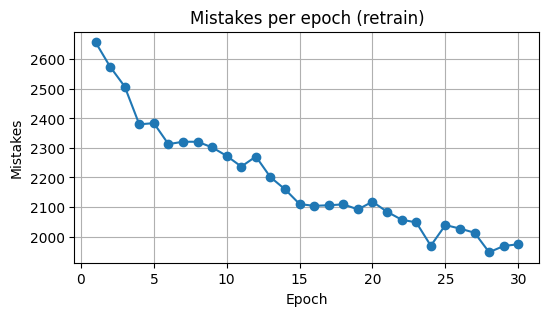

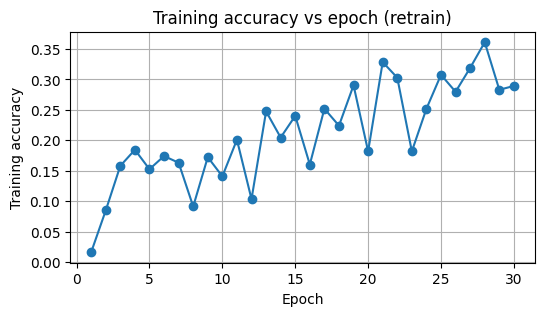

In [32]:
# model_best.history contains mistakes and train_acc from retraining on train+val
hist = model_best.history
plt.figure(figsize=(6,3))
plt.plot(hist["epoch"], hist["mistakes"], marker='o')
plt.xlabel("Epoch"); plt.ylabel("Mistakes"); plt.title("Mistakes per epoch (retrain)")
plt.grid(True); plt.show()

plt.figure(figsize=(6,3))
plt.plot(hist["epoch"], hist["train_acc"], marker='o')
plt.xlabel("Epoch"); plt.ylabel("Training accuracy"); plt.title("Training accuracy vs epoch (retrain)")
plt.grid(True); plt.show()
